Please upload your heart disease ZIP file.


Saving heart+disease.zip to heart+disease.zip

Uploaded file(s):
['heart+disease.zip']

ZIP file found:
heart+disease.zip

ZIP file extracted successfully.

Dataset found at:
heart_disease_data/processed.cleveland.data

Dataset loaded successfully.

Dataset shape:
(303, 14)

First 5 rows:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  num  
0    3.0  0.0   6.0    0  
1    2.0  3.0   3.0    2  
2    2.0  2.0   7.0    1  
3    3.0  0.0   3.0    0  
4    1.0  0.0   3.0    0  

COLUMN NAMES
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', '

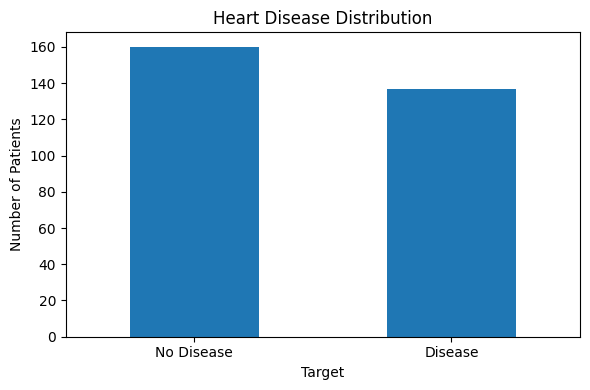

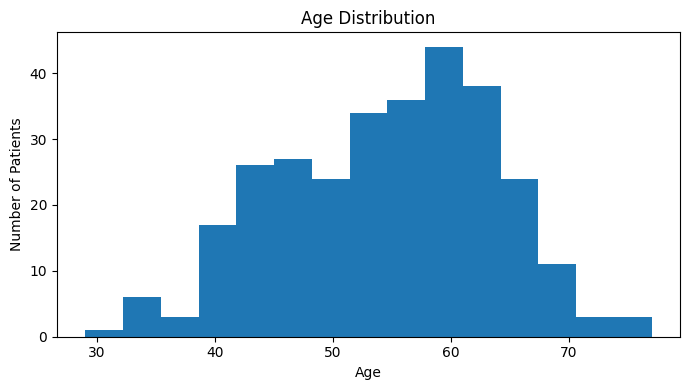

<Figure size 600x400 with 0 Axes>

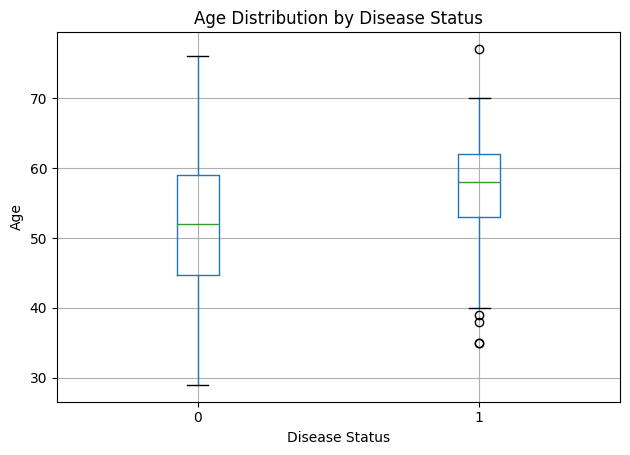

<Figure size 600x400 with 0 Axes>

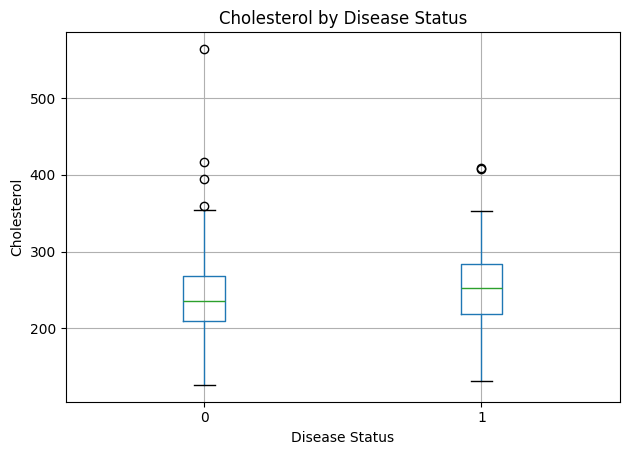


FEATURES AND TARGET
X shape: (297, 13)
y shape: (297,)

Features:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

TRAIN / TEST SPLIT
X_train: (237, 13)
X_test : (60, 13)
y_train: (237,)
y_test : (60,)

LOGISTIC REGRESSION
Accuracy: 0.8333333333333334
Accuracy (%): 83.33333333333334

DECISION TREE
Accuracy: 0.75
Accuracy (%): 75.0

RANDOM FOREST
Accuracy: 0.8666666666666667
Accuracy (%): 86.66666666666667

MODEL COMPARISON
              Model  Accuracy  Precision   Recall  F1 Score
Logistic Regression  0.833333   0.846154 0.785714  0.814815
      Decision Tree  0.750000   0.760000 0.678571  0.716981
      Random Forest  0.866667   0.884615 0.821429  0.851852

BEST MODEL
Model        Random Forest
Accuracy          0.866667
Precision         0.884615
Recall            0.821429
F1 Score          0.851852
Name: 2, dtype: object

LOGISTIC REGRESSION CLASSIFICATION REPORT
              precision    recall  f1-score   support


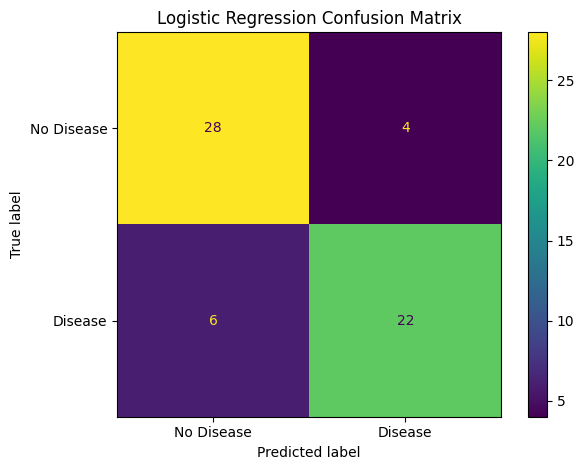


FEATURE IMPORTANCE
 Feature  Importance
    thal    0.135143
      cp    0.134247
 thalach    0.116589
 oldpeak    0.104982
      ca    0.096142
    chol    0.092078
     age    0.090664
trestbps    0.076257
   slope    0.053829
   exang    0.044552
     sex    0.025302
 restecg    0.021016
     fbs    0.009199


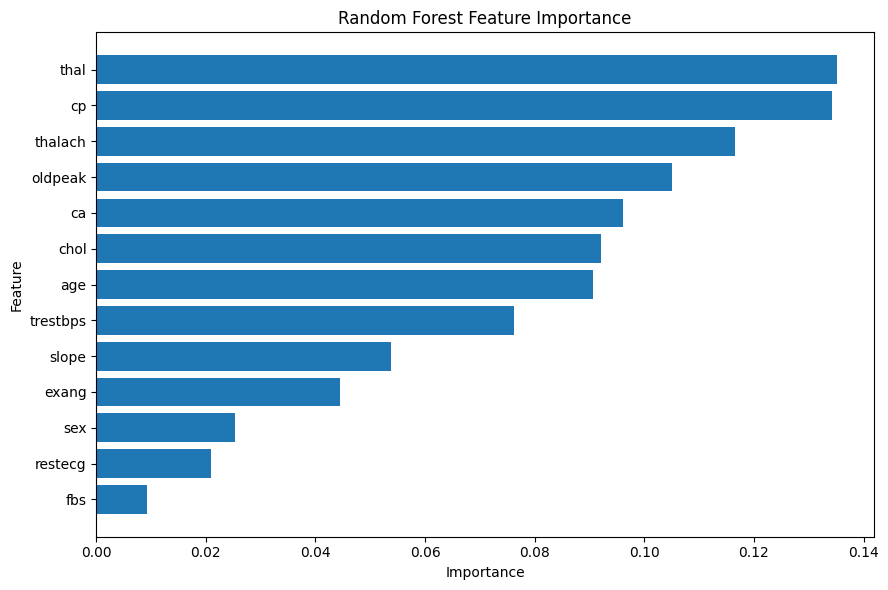


SAMPLE PATIENT PREDICTION
Predicted class: 0
Prediction: No Disease
Probability of No Disease: 0.96
Probability of Disease: 0.04

PROJECT COMPLETED
Models saved successfully.

Final model comparison:
              Model  Accuracy  Precision   Recall  F1 Score
Logistic Regression  0.833333   0.846154 0.785714  0.814815
      Decision Tree  0.750000   0.760000 0.678571  0.716981
      Random Forest  0.866667   0.884615 0.821429  0.851852

Best model based on F1 Score:
Random Forest


In [1]:
# ============================================================
# PROJECT 1: HEART DISEASE PREDICTION
# Complete End-to-End Machine Learning Project
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import glob
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)


# ============================================================
# 2. UPLOAD DATASET
# ============================================================

print("Please upload your heart disease ZIP file.")

uploaded = files.upload()

print("\nUploaded file(s):")
print(list(uploaded.keys()))


# ============================================================
# 3. FIND AND EXTRACT ZIP FILE
# ============================================================

zip_files = glob.glob("*.zip")

if len(zip_files) == 0:
    raise FileNotFoundError(
        "No ZIP file was found. Please upload the heart disease ZIP file."
    )

zip_file = zip_files[0]

print("\nZIP file found:")
print(zip_file)

extract_folder = "heart_disease_data"

os.makedirs(extract_folder, exist_ok=True)

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(extract_folder)

print("\nZIP file extracted successfully.")


# ============================================================
# 4. FIND processed.cleveland.data AUTOMATICALLY
# ============================================================

cleveland_files = glob.glob(
    extract_folder + "/**/processed.cleveland.data",
    recursive=True
)

if len(cleveland_files) == 0:
    raise FileNotFoundError(
        "processed.cleveland.data was not found inside the ZIP file."
    )

file_path = cleveland_files[0]

print("\nDataset found at:")
print(file_path)


# ============================================================
# 5. LOAD DATASET
# ============================================================

df = pd.read_csv(
    file_path,
    header=None,
    na_values="?"
)

columns = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "num"
]

df.columns = columns

print("\nDataset loaded successfully.")

print("\nDataset shape:")
print(df.shape)

print("\nFirst 5 rows:")
print(df.head())


# ============================================================
# 6. BASIC DATA INFORMATION
# ============================================================

print("\n" + "="*60)
print("COLUMN NAMES")
print("="*60)

print(df.columns.tolist())


print("\n" + "="*60)
print("DATA INFORMATION")
print("="*60)

df.info()


print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)

print(df.isnull().sum())


# ============================================================
# 7. STATISTICAL SUMMARY
# ============================================================

print("\n" + "="*60)
print("STATISTICAL SUMMARY")
print("="*60)

print(df.describe())


# ============================================================
# 8. CLEAN DATA
# ============================================================

print("\n" + "="*60)
print("DATA CLEANING")
print("="*60)

print("Original dataset shape:", df.shape)

df_clean = df.dropna().copy()

print("Cleaned dataset shape:", df_clean.shape)

print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())


# ============================================================
# 9. CREATE BINARY TARGET
# ============================================================

print("\n" + "="*60)
print("CREATING TARGET VARIABLE")
print("="*60)

# Original num:
# 0 = no disease
# 1,2,3,4 = disease

df_clean["target"] = (df_clean["num"] > 0).astype(int)

print(df_clean[["num", "target"]].head(10))

print("\nTarget distribution:")
print(df_clean["target"].value_counts())


# ============================================================
# 10. REMOVE ORIGINAL num COLUMN
# ============================================================

df_clean = df_clean.drop(columns=["num"])

print("\nFinal dataset shape:")
print(df_clean.shape)

print("\nFinal columns:")
print(df_clean.columns.tolist())


# ============================================================
# 11. EDA — TARGET DISTRIBUTION
# ============================================================

plt.figure(figsize=(6, 4))

df_clean["target"].value_counts().sort_index().plot(kind="bar")

plt.title("Heart Disease Distribution")
plt.xlabel("Target")
plt.ylabel("Number of Patients")
plt.xticks(
    [0, 1],
    ["No Disease", "Disease"],
    rotation=0
)

plt.tight_layout()
plt.show()


# ============================================================
# 12. EDA — AGE DISTRIBUTION
# ============================================================

plt.figure(figsize=(7, 4))

plt.hist(
    df_clean["age"],
    bins=15
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()


# ============================================================
# 13. EDA — AGE VS DISEASE
# ============================================================

plt.figure(figsize=(6, 4))

df_clean.boxplot(
    column="age",
    by="target"
)

plt.title("Age Distribution by Disease Status")
plt.suptitle("")
plt.xlabel("Disease Status")
plt.ylabel("Age")

plt.tight_layout()
plt.show()


# ============================================================
# 14. EDA — CHOLESTEROL VS DISEASE
# ============================================================

plt.figure(figsize=(6, 4))

df_clean.boxplot(
    column="chol",
    by="target"
)

plt.title("Cholesterol by Disease Status")
plt.suptitle("")
plt.xlabel("Disease Status")
plt.ylabel("Cholesterol")

plt.tight_layout()
plt.show()


# ============================================================
# 15. SEPARATE FEATURES AND TARGET
# ============================================================

X = df_clean.drop(columns=["target"])

y = df_clean["target"]

print("\n" + "="*60)
print("FEATURES AND TARGET")
print("="*60)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())


# ============================================================
# 16. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n" + "="*60)
print("TRAIN / TEST SPLIT")
print("="*60)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


# ============================================================
# 17. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


# ============================================================
# 18. LOGISTIC REGRESSION
# ============================================================

print("\n" + "="*60)
print("LOGISTIC REGRESSION")
print("="*60)

logistic_model = LogisticRegression(
    max_iter=1000
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

y_pred_logistic = logistic_model.predict(
    X_test_scaled
)

logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

print("Accuracy:", logistic_accuracy)
print("Accuracy (%):", logistic_accuracy * 100)


# ============================================================
# 19. DECISION TREE
# ============================================================

print("\n" + "="*60)
print("DECISION TREE")
print("="*60)

tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

tree_model.fit(
    X_train,
    y_train
)

y_pred_tree = tree_model.predict(
    X_test
)

tree_accuracy = accuracy_score(
    y_test,
    y_pred_tree
)

print("Accuracy:", tree_accuracy)
print("Accuracy (%):", tree_accuracy * 100)


# ============================================================
# 20. RANDOM FOREST
# ============================================================

print("\n" + "="*60)
print("RANDOM FOREST")
print("="*60)

forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

forest_model.fit(
    X_train,
    y_train
)

y_pred_forest = forest_model.predict(
    X_test
)

forest_accuracy = accuracy_score(
    y_test,
    y_pred_forest
)

print("Accuracy:", forest_accuracy)
print("Accuracy (%):", forest_accuracy * 100)


# ============================================================
# 21. COMPARE ALL MODELS
# ============================================================

print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)

models = {
    "Logistic Regression": y_pred_logistic,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_forest
}

results = []

for model_name, predictions in models.items():

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),
        "Precision": precision_score(
            y_test,
            predictions
        ),
        "Recall": recall_score(
            y_test,
            predictions
        ),
        "F1 Score": f1_score(
            y_test,
            predictions
        )
    })

results_df = pd.DataFrame(results)

print(results_df.to_string(index=False))


# ============================================================
# 22. SELECT BEST MODEL
# ============================================================

best_model_row = results_df.loc[
    results_df["F1 Score"].idxmax()
]

best_model_name = best_model_row["Model"]

print("\n" + "="*60)
print("BEST MODEL")
print("="*60)

print(best_model_row)


# ============================================================
# 23. DETAILED EVALUATION OF LOGISTIC REGRESSION
# ============================================================

print("\n" + "="*60)
print("LOGISTIC REGRESSION CLASSIFICATION REPORT")
print("="*60)

print(
    classification_report(
        y_test,
        y_pred_logistic
    )
)


# ============================================================
# 24. CONFUSION MATRIX
# ============================================================

print("\n" + "="*60)
print("CONFUSION MATRIX")
print("="*60)

cm = confusion_matrix(
    y_test,
    y_pred_logistic
)

print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease", "Disease"]
).plot()

plt.title("Logistic Regression Confusion Matrix")

plt.tight_layout()
plt.show()


# ============================================================
# 25. RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

print("\n" + "="*60)
print("FEATURE IMPORTANCE")
print("="*60)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.to_string(index=False))


plt.figure(figsize=(9, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


# ============================================================
# FINAL SAMPLE PREDICTION
# ============================================================

print("\n" + "="*60)
print("SAMPLE PATIENT PREDICTION")
print("="*60)

sample_patient = X_test.iloc[[0]]

prediction = forest_model.predict(
    sample_patient
)

probability = forest_model.predict_proba(
    sample_patient
)

print("Predicted class:", prediction[0])

if prediction[0] == 1:
    print("Prediction: Disease")
else:
    print("Prediction: No Disease")

print(
    "Probability of No Disease:",
    probability[0][0]
)

print(
    "Probability of Disease:",
    probability[0][1]
)


# ============================================================
# SAVE MODELS
# ============================================================

joblib.dump(
    forest_model,
    "heart_disease_random_forest.pkl"
)

joblib.dump(
    logistic_model,
    "heart_disease_logistic_regression.pkl"
)

joblib.dump(
    scaler,
    "heart_disease_scaler.pkl"
)

print("\n" + "="*60)
print("PROJECT COMPLETED")
print("="*60)

print("Models saved successfully.")

print("\nFinal model comparison:")
print(results_df.to_string(index=False))

print("\nBest model based on F1 Score:")
print(best_model_name)